In [1]:
# import all libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [2]:
# load csv
base_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')

C:\Users\Golbe\AppData\Local\Temp\ipykernel_35676\4063985396.py:2: DtypeWarning: Columns (18,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  base_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')


In [3]:
# In case you do not know the id associated with a player you can insert a full name or part of a name in this lookup tool
player_name = 'Roger Federer'

base_df[['player_name','player_id','player_country','tourney_name','tourney_date','player_rank','elo']][base_df['player_name'].str.contains(player_name)]

,player_name,player_id,player_country,tourney_name,tourney_date,player_rank,elo
223422,Roger Federer,103819,SUI,Basel,1999-10-04,106.0,1511.603702
223423,Roger Federer,103819,SUI,Adelaide,2000-01-03,64.0,1527.715787
223424,Roger Federer,103819,SUI,Adelaide,2000-01-03,64.0,1512.046412
223425,Roger Federer,103819,SUI,Auckland,2000-01-10,61.0,1495.491876
223426,Roger Federer,103819,SUI,Australian Open,2000-01-17,62.0,1515.640714
...,...,...,...,...,...,...,...
224909,Roger Federer,103819,SUI,Wimbledon,2021-06-28,8.0,2575.355833
224910,Roger Federer,103819,SUI,Wimbledon,2021-06-28,8.0,2579.039516
224911,Roger Federer,103819,SUI,Wimbledon,2021-06-28,8.0,2588.284246
224912,Roger Federer,103819,SUI,Wimbledon,2021-06-28,8.0,2594.342819


## IMPORTANT!!!
DISABLE THE PLAYER HERE. IF NO PLAYER_ID IS PASSED IT WILL USE THE WHOLE DATASET

In [4]:
# put the player id and years of experience of the player you want to look up here
excluded_player = 103819
less_than_years = 7

only_players = base_df[['player_name','player_id']]
only_players = only_players.drop_duplicates()
name_chosen_player = only_players['player_name'][only_players['player_id'] == excluded_player].iloc[0]

## Rest of normal flow

In [5]:
# extra assignment to reset dataframe if a mistake is made during processing
full_df = base_df.copy()
len(full_df)

1282807

In [6]:
selected_features = [
'player_id', # needed to know what player to keep or drop
# 'surface', 
'tourney_level', 
# 'tourney_date', # dropped because not numeric 
'match_num', 
#'player_height', 
# 'player_country', 
'player_age', 
# 'elo_pre_match', # derrived target
# 'opponent_elo_pre_match', 
#'opponent_rank', 
# 'mean_numb', # dropped as the rolling means are derrivitives of these columns and adding the raw ones creates a worse model and increases conlinearity
# 'median_numb', 
# 'total_numb', 
# 'mean_diff', 
# 'median_diff', 
# 'total_diff', 
# 'mean_tb_numb', 
# 'median_tb_numb', 
# 'total_tb_numb', 
# 'mean_tb_diff', 
# 'median_tb_diff', 
# 'total_tb_diff', 
'days_of_experience',
# 'career_year', 
# 'rest_days', 
# 'set_dominance', 
# 'tb_dominance', 
#'highest_finish_position', 
'draw_size_rolling_med_10', 
'highest_finish_position_rolling_med_10', 
# 'ace_rolling_mean_10', 
# 'double_faults_rolling_mean_10', # drop these so that most low level players are included
# 'points_on_serve_rolling_mean_10', 
# 'first_serve_in_rolling_mean_10', 
# '1stWon_rolling_mean_10', 
# '2ndWon_rolling_mean_10', 
# 'service_games_rolling_mean_10', 
# 'break_points_saved_rolling_mean_10', 
# 'break_points_faced_rolling_mean_10', 
# 'elo_pre_match_rolling_mean_10',
# 'opponent_elo_pre_match_rolling_mean_10', 
'set_dominance_rolling_mean_10', 
'tb_dominance_rolling_mean_10', 
#'player_rank_rolling_mean_10', # dropped because the model will cheat with this if predicting rank
'mean_numb_rolling_mean_10', 
#'median_numb_rolling_mean_10', 
#'total_numb_rolling_mean_10', 
'mean_diff_rolling_mean_10', 
#'median_diff_rolling_mean_10', 
#'total_diff_rolling_mean_10', 
'mean_tb_numb_rolling_mean_10', 
#'median_tb_numb_rolling_mean_10', 
#'total_tb_numb_rolling_mean_10', 
'mean_tb_diff_rolling_mean_10', 
#'median_tb_diff_rolling_mean_10', 
#'total_tb_diff_rolling_mean_10', 
'elo' # target, same as elo post match 
]

In [7]:
print(full_df.shape)

(1282807, 132)


replace all nan values with 0

In [8]:
full_df[['median_tb_diff','mean_tb_numb','median_tb_numb','mean_tb_diff','tb_dominance',
         'draw_size_rolling_med_10', 'highest_finish_position_rolling_med_10', 'ace_rolling_mean_10', 
        'double_faults_rolling_mean_10', 'points_on_serve_rolling_mean_10', 'first_serve_in_rolling_mean_10',
        '1stWon_rolling_mean_10', '2ndWon_rolling_mean_10', 'service_games_rolling_mean_10', 'break_points_saved_rolling_mean_10',
        'break_points_faced_rolling_mean_10','elo_pre_match_rolling_mean_10','opponent_elo_pre_match_rolling_mean_10', 
        'set_dominance_rolling_mean_10','tb_dominance_rolling_mean_10','player_rank_rolling_mean_10', 'mean_numb_rolling_mean_10', 
        'median_numb_rolling_mean_10','total_numb_rolling_mean_10','mean_diff_rolling_mean_10','median_diff_rolling_mean_10', 
        'total_diff_rolling_mean_10','mean_tb_numb_rolling_mean_10','median_tb_numb_rolling_mean_10','total_tb_numb_rolling_mean_10', 
        'mean_tb_diff_rolling_mean_10','median_tb_diff_rolling_mean_10','total_tb_diff_rolling_mean_10']] = full_df[['median_tb_diff','mean_tb_numb','median_tb_numb','mean_tb_diff','tb_dominance','draw_size_rolling_med_10', 'highest_finish_position_rolling_med_10', 'ace_rolling_mean_10', 
        'double_faults_rolling_mean_10', 'points_on_serve_rolling_mean_10', 'first_serve_in_rolling_mean_10',
        '1stWon_rolling_mean_10', '2ndWon_rolling_mean_10', 'service_games_rolling_mean_10', 'break_points_saved_rolling_mean_10',
        'break_points_faced_rolling_mean_10','elo_pre_match_rolling_mean_10','opponent_elo_pre_match_rolling_mean_10', 
        'set_dominance_rolling_mean_10','tb_dominance_rolling_mean_10','player_rank_rolling_mean_10', 'mean_numb_rolling_mean_10', 
        'median_numb_rolling_mean_10','total_numb_rolling_mean_10','mean_diff_rolling_mean_10','median_diff_rolling_mean_10', 
        'total_diff_rolling_mean_10','mean_tb_numb_rolling_mean_10','median_tb_numb_rolling_mean_10','total_tb_numb_rolling_mean_10', 
        'mean_tb_diff_rolling_mean_10','median_tb_diff_rolling_mean_10','total_tb_diff_rolling_mean_10']].replace(np.nan,0)

In [9]:
# fill missing elo with baseline as that is where everything starts
print(full_df['elo'].isna().sum())
full_df['elo'] = full_df['elo'].replace(np.nan,1500)
print(full_df['elo'].isna().sum())

# also make one without nan values to compare
print(base_df['elo'].isna().sum())
full_df_2 = base_df[base_df['elo'].notna()]
print(full_df_2['elo'].isna().sum())

19267
0
19267
0


Create the max player elo and join to full_df as best elo reached

In [10]:
best_elo_filled = full_df.groupby('player_id', as_index=False)['elo'].max()
best_elo_filled = best_elo_filled.rename(columns={'elo':'best_elo_reached'})

full_df = pd.merge(left=full_df,right=best_elo_filled,how='left',on='player_id')

best_elo_dropped = full_df_2.groupby('player_id', as_index=False)['elo'].max()
best_elo_dropped = best_elo_dropped.rename(columns={'elo':'best_elo_reached'})

full_df_2 = pd.merge(left=full_df_2,right=best_elo_dropped,how='left',on='player_id')

In [11]:
# select all features to use in the prediction
print(len(full_df))
df_subset = full_df[selected_features]
print(len(df_subset))

1282807
1282807


In [12]:
df_subset.isna().sum().sort_values(ascending=False)

player_id                                 0
tourney_level                             0
match_num                                 0
player_age                                0
days_of_experience                        0
draw_size_rolling_med_10                  0
highest_finish_position_rolling_med_10    0
set_dominance_rolling_mean_10             0
tb_dominance_rolling_mean_10              0
mean_numb_rolling_mean_10                 0
mean_diff_rolling_mean_10                 0
mean_tb_numb_rolling_mean_10              0
mean_tb_diff_rolling_mean_10              0
elo                                       0
dtype: int64

In [13]:
# drop all values where nan because knn cannot deal with empty values
df_subset = df_subset.dropna()

In [14]:
df_subset.isna().sum().sort_values(ascending=False)

player_id                                 0
tourney_level                             0
match_num                                 0
player_age                                0
days_of_experience                        0
draw_size_rolling_med_10                  0
highest_finish_position_rolling_med_10    0
set_dominance_rolling_mean_10             0
tb_dominance_rolling_mean_10              0
mean_numb_rolling_mean_10                 0
mean_diff_rolling_mean_10                 0
mean_tb_numb_rolling_mean_10              0
mean_tb_diff_rolling_mean_10              0
elo                                       0
dtype: int64

From testing, the categorical columns tend to add little value to the prediction besides tourney_level. Removing them creates a better model for all metrics

In [15]:
# # Print non numeric columns
print(len(df_subset))
numeric_cols = df_subset.select_dtypes(exclude=[np.number]).columns
print(numeric_cols)

# encode non numeric values
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop first to avoid multicollinearity
surface_encoded = encoder.fit_transform(df_subset[[
    # 'surface',
    #'player_country',
    'tourney_level'
    ]])
surface_df = pd.DataFrame(surface_encoded, 
                          columns=encoder.get_feature_names_out([
    #'surface',
    #'player_country',
    'tourney_level'
                                                                 ]),
                          index=df_subset.index)
df_encoded = pd.concat([df_subset.drop([
    #'surface',
    #'player_country',
    'tourney_level'
    ], axis=1), surface_df], axis=1)
#df_encoded = df_subset
print(len(df_encoded))

1282807
Index(['tourney_level'], dtype='object')
1282807


## Remove the player that was specified from the train/test data using the player id column and drop that column

In [16]:
# remove the player from the dataset if id is specified
if excluded_player:
    # copy to not mess with the original df
    df_encoded_xp = df_encoded.copy()
    excluded_player_df = df_encoded_xp[df_encoded_xp.player_id == excluded_player]
    df_encoded = df_encoded_xp[df_encoded_xp.player_id != excluded_player]
    excluded_player_df = excluded_player_df.drop(columns='player_id')

# drop player_id regardless
df_encoded = df_encoded.drop(columns='player_id')

## Continue as normal

In [17]:
# make a subset of the data for finding the ideal amount of neighbors
df_subset = df_encoded.sample(frac=0.01, random_state=42)

In [18]:
# prepare data
X = df_encoded.drop('elo', axis=1)  # Features
y = df_encoded['elo']  # Target

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features to normalise
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# train
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# predict
y_pred = lin_reg.predict(X_test_scaled)

# metrics
test_r2_score = r2_score(y_test, y_pred)
mean_sqr_error = mean_squared_error(y_test, y_pred)
mean_abs_error = mean_absolute_error(y_test, y_pred)
root_mean_sqr_error = root_mean_squared_error(y_test, y_pred)

print(f"R2 score: {test_r2_score:.4f}")
print(f"Mean Squared Error (MSE): {mean_sqr_error:.4f}")
print(f"Mean Absolute Error (MAE): {mean_abs_error:.4f}")
print(f"Root Mean Squared Error (RMSE): {root_mean_sqr_error:.4f}")

# Check if there's overfitting
train_score = lin_reg.score(X_train_scaled, y_train)
test_score = lin_reg.score(X_test_scaled, y_test)
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy: {test_score:.4f}")

R2 score: 0.7277
Mean Squared Error (MSE): 14776.4576
Mean Absolute Error (MAE): 91.7630
Root Mean Squared Error (RMSE): 121.5585
Train accuracy: 0.7282
Test accuracy: 0.7277


In [48]:
y_df = pd.DataFrame(zip(y_pred,y_test),columns=['predicted_best_elo','real_best_elo'])
results = X_test.copy()

results = pd.concat([results,y_df],axis=1)

results['elo_points_off_rounded'] = round(results['real_best_elo'] - results['predicted_best_elo'],0)
results['abs_elo_points_off_rounded'] = abs(results['elo_points_off_rounded'])

# make uniform bins for visualisation
results["binned_abs_elo_points_off_rounded"] = pd.cut(
    results["elo_points_off_rounded"],
    bins=20,
    labels=False
)

results

,match_num,player_age,days_of_experience,draw_size_rolling_med_10,highest_finish_position_rolling_med_10,set_dominance_rolling_mean_10,tb_dominance_rolling_mean_10,mean_numb_rolling_mean_10,mean_diff_rolling_mean_10,mean_tb_numb_rolling_mean_10,...,tourney_level_F,tourney_level_G,tourney_level_M,tourney_level_O,tourney_level_S,predicted_best_elo,real_best_elo,elo_points_off_rounded,abs_elo_points_off_rounded,binned_abs_elo_points_off_rounded
646182,19.0,24.0,2415.0,32.0,9.0,0.50,0.333333,5.64,1.400000e-01,4.333333,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
894228,14.0,22.0,1351.0,32.0,9.0,0.52,0.500000,5.56,5.528911e-15,5.000000,...,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
506110,1.0,24.0,3157.0,56.0,1.5,0.40,0.000000,5.78,3.800000e-01,0.000000,...,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1093335,304.0,28.0,3836.0,32.0,9.0,0.50,1.000000,5.46,-2.600000e-01,5.500000,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
612749,14.0,20.0,1330.0,32.0,17.0,0.56,0.000000,5.46,-4.400000e-01,1.000000,...,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1900.016705,1997.472661,97.0,97.0,13.0
256259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1562.311587,1882.351699,320.0,320.0,15.0
256260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1492.202323,1596.225561,104.0,104.0,13.0
256261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1604.111399,1485.149941,-119.0,119.0,11.0


## Visualisations for whole dataset

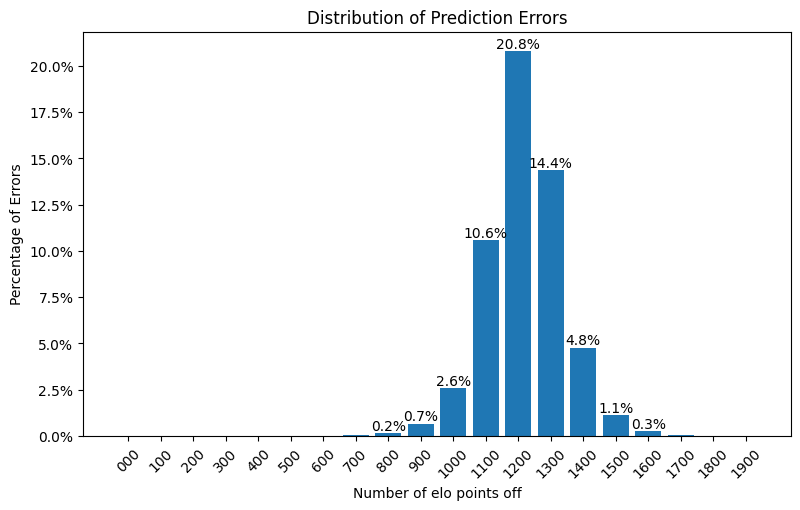

In [ ]:
counts = results['binned_abs_elo_points_off_rounded'].value_counts().sort_index()/len(results)

plt.figure(figsize=(8,5))
plt.xlabel("Number of elo points off")
plt.ylabel("Percentage of Errors")
plt.title(f"Distribution of Prediction Errors")
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
bars = plt.bar(counts.index.astype(str), counts.values)
for bar in bars:
    height = bar.get_height()
    if height >= 0.001:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom"
        )

#plt.bar(range(len(counts)), counts.values)
#plt.plot(counts.values)
plt.xticks(range(len(counts)), counts.index.astype(int).astype(str)+'00', rotation=45)
plt.show()

In [ ]:
# True distribution
counts = df_encoded['elo'].value_counts().sort_index() / len(df_encoded)

# Predicted distribution
pred_counts = results['predicted_best_elo'].value_counts().sort_index() / len(results)

x = np.arange(len(counts))  # x positions
width = 0.35  # width of bars

plt.figure(figsize=(8,5))
bars_true = plt.bar(x - width/2, counts.values, width=width, label='Real Population', color='seagreen')
bars_pred = plt.bar(x + width/2, pred_counts.values, width=width, label='Predicted Population', color='orangered')

plt.xlabel("Player bins")
plt.ylabel("Proportion of Total")
plt.title("True vs Predicted Player Bin Distribution")
plt.legend()
plt.tight_layout()

plt.show()

KeyboardInterrupt: 

## Validation and visualisation for the excluded player

In [ ]:
if excluded_player:
    y_test_player_excluded = excluded_player_df['binned_elo']
    X_player_excluded = excluded_player_df.drop('binned_elo', axis=1)
    X_player_excluded_scaled = scaler.transform(X_player_excluded)
    y_pred_player_excluded = lin_reg.predict(X_player_excluded_scaled)

else:
    print('player_id was empty')

In [ ]:
if excluded_player:
    
    # Percentage of correctly predicted max elo
    guessed_correctly = (y_pred_player_excluded == y_test_player_excluded).mean()
    print(f"Percentage of players correctly guessed for a particular player (Accuracy): {guessed_correctly}")

    # confusion matrix for the player
    cm_xp = confusion_matrix(
    y_test_player_excluded, 
    y_pred_player_excluded, 
    labels=list(range(len(bin_labels)))  # ensures 0,1,2,3,4,5 all appear
    )

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_xp, annot=True, fmt="d", cmap="Blues",xticklabels=bin_labels,yticklabels=bin_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {name_chosen_player}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.show()

    # create a dataframe of the results
    excluded_player_results = pd.DataFrame({
        'predicted_peak_elo_encoded':y_pred_player_excluded,
        'true_peak_elo_encoded':y_test_player_excluded,
        'correctly_predicted':y_pred_player_excluded==y_test_player_excluded
        })
    # merge the results with the x too get a full view and be able to visualise it
    excluded_player_final = pd.concat([X_player_excluded,excluded_player_results],axis=1)

    lower_bounds = [int(label.split('-')[0]) for label in bin_labels]
    upper_bounds = [int(label.split('-')[1]) for label in bin_labels]

    # Create a lookup dictionary from encoded bin -> bound
    lower_dict = dict(enumerate(lower_bounds))
    upper_dict = dict(enumerate(upper_bounds))

    # Add new columns directly
    excluded_player_final['predicted_lower'] = excluded_player_final['predicted_peak_elo_encoded'].map(lower_dict)
    excluded_player_final['predicted_upper'] = excluded_player_final['predicted_peak_elo_encoded'].map(upper_dict)

    excluded_player_final['true_lower'] = excluded_player_final['true_peak_elo_encoded'].map(lower_dict)
    excluded_player_final['true_upper'] = excluded_player_final['true_peak_elo_encoded'].map(upper_dict)

    # bin the days of experience to reduce the data points on the graph
    excluded_player_final['days_bin'] = (excluded_player_final['days_of_experience'] // 30) * 30

    # show predicted vs true as labled values (easier to look at than ranks)
    plt.scatter(excluded_player_final['days_bin'], excluded_player_final['predicted_peak_elo_encoded'], color='red', label='Predicted elo')
    plt.plot(excluded_player_final['days_bin'], excluded_player_final['true_peak_elo_encoded'], color='blue', label='True elo')
    plt.xlabel('Days of Experience')
    plt.ylabel(f'Elo bucket for {name_chosen_player}')
    plt.title(f'Highest elo bucket vs predicted elo for {name_chosen_player}')
    plt.legend()
    # make sure that the ticks are full integers
    ax = plt.gca()
    ax.set_yticks([0,1,2,3,4,5])
    ax.set_yticklabels([0,1,2,3,4,5])
    plt.show()

    # get the last value from days bin where the pred was wrong
    last_wrong_pred_day_plus_30 = excluded_player_final[excluded_player_final['correctly_predicted'] == 0][['days_bin']].iloc[-1,0]+30
    zoomed_excluded_player_df = excluded_player_final[excluded_player_final['days_bin'] <= last_wrong_pred_day_plus_30]
    
    # 
    df = zoomed_excluded_player_df[['days_bin', 'predicted_peak_elo_encoded']].copy()
    counts = df.groupby(['days_bin', 'predicted_peak_elo_encoded']).size().reset_index(name='count')

    plt.xlabel('Days of Experience')
    plt.ylabel(f'Elo bucket for {name_chosen_player}')
    plt.title(f'Highest elo vs Predicted elo for {name_chosen_player} \nZoomed on wrong predictions')
    plt.scatter(zoomed_excluded_player_df['days_bin'], zoomed_excluded_player_df['predicted_peak_elo_encoded'],color='red',label='Predicted elo')
    plt.axhline(y=zoomed_excluded_player_df['true_peak_elo_encoded'].iloc[-1], color='blue', linestyle='-', linewidth=1, label='True peak elo')

    # create labels for places where points overlap
    for _, row in counts.iterrows():
        if row['count'] > 1:
            plt.text(row['days_bin'], row['predicted_peak_elo_encoded']-0.18, str(row['count']),
                    fontsize=8, ha='center', va='center')

    # make sure that the ticks are full integers
    ax = plt.gca()
    ax.set_yticks([0,1,2,3,4,5])
    ax.set_yticklabels([0,1,2,3,4,5])
    plt.legend()
    plt.show()